In [1]:
import pandas as pd
import numpy as np

In [2]:
import seaborn as sns

In [3]:
df = pd.read_csv('auto-mpg.csv')
df

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino
...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86,2790,15.6,82,1,ford mustang gl
394,44.0,4,97.0,52,2130,24.6,82,2,vw pickup
395,32.0,4,135.0,84,2295,11.6,82,1,dodge rampage
396,28.0,4,120.0,79,2625,18.6,82,1,ford ranger


In [4]:
df = df.loc[df['horsepower'] != '?']

<Axes: ylabel='horsepower'>

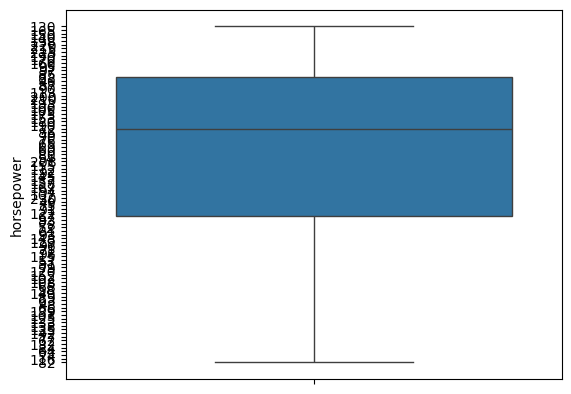

In [5]:
sns.boxplot(data = df['horsepower'])

In [6]:
df['horsepower'] = df["horsepower"].astype(int)

C:\Users\LJENG\AppData\Local\Temp\ipykernel_7944\870389709.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['horsepower'] = df["horsepower"].astype(int)


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 392 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           392 non-null    float64
 1   cylinders     392 non-null    int64  
 2   displacement  392 non-null    float64
 3   horsepower    392 non-null    int64  
 4   weight        392 non-null    int64  
 5   acceleration  392 non-null    float64
 6   model year    392 non-null    int64  
 7   origin        392 non-null    int64  
 8   car name      392 non-null    object 
dtypes: float64(3), int64(5), object(1)
memory usage: 30.6+ KB


In [8]:
df.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin
count,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000
mean,23.445918,5.471939,194.411990,104.469388,2977.584184,15.541327,75.979592,1.576531
std,7.805007,1.705783,104.644004,38.491160,849.402560,2.758864,3.683737,0.805518
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.000000,4.000000,105.000000,75.000000,2225.250000,13.775000,73.000000,1.000000
50%,22.750000,4.000000,151.000000,93.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,275.750000,126.000000,3614.750000,17.025000,79.000000,2.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000,3.000000


In [9]:
q1 = df['horsepower'].quantile(0.25)
q3 = df['horsepower'].quantile(0.75)
iqr = 1.5*(q3-q1)
print(q1-iqr)
print(q3+iqr)
ur = q3+iqr
lr = q1-iqr
df = df.loc[(df['horsepower']>lr) & (df['horsepower']<ur)]

-1.5
202.5


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 382 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           382 non-null    float64
 1   cylinders     382 non-null    int64  
 2   displacement  382 non-null    float64
 3   horsepower    382 non-null    int64  
 4   weight        382 non-null    int64  
 5   acceleration  382 non-null    float64
 6   model year    382 non-null    int64  
 7   origin        382 non-null    int64  
 8   car name      382 non-null    object 
dtypes: float64(3), int64(5), object(1)
memory usage: 29.8+ KB


<Axes: ylabel='acceleration'>

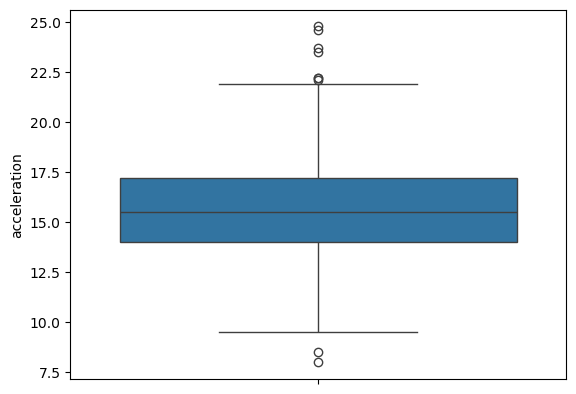

In [11]:
sns.boxplot(data = df['acceleration'])

<Axes: >

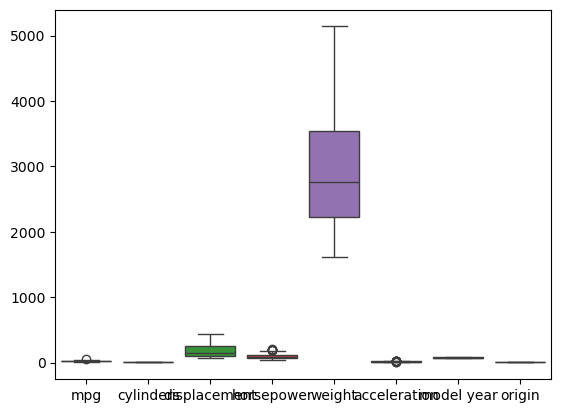

In [12]:
sns.boxplot(data=df)

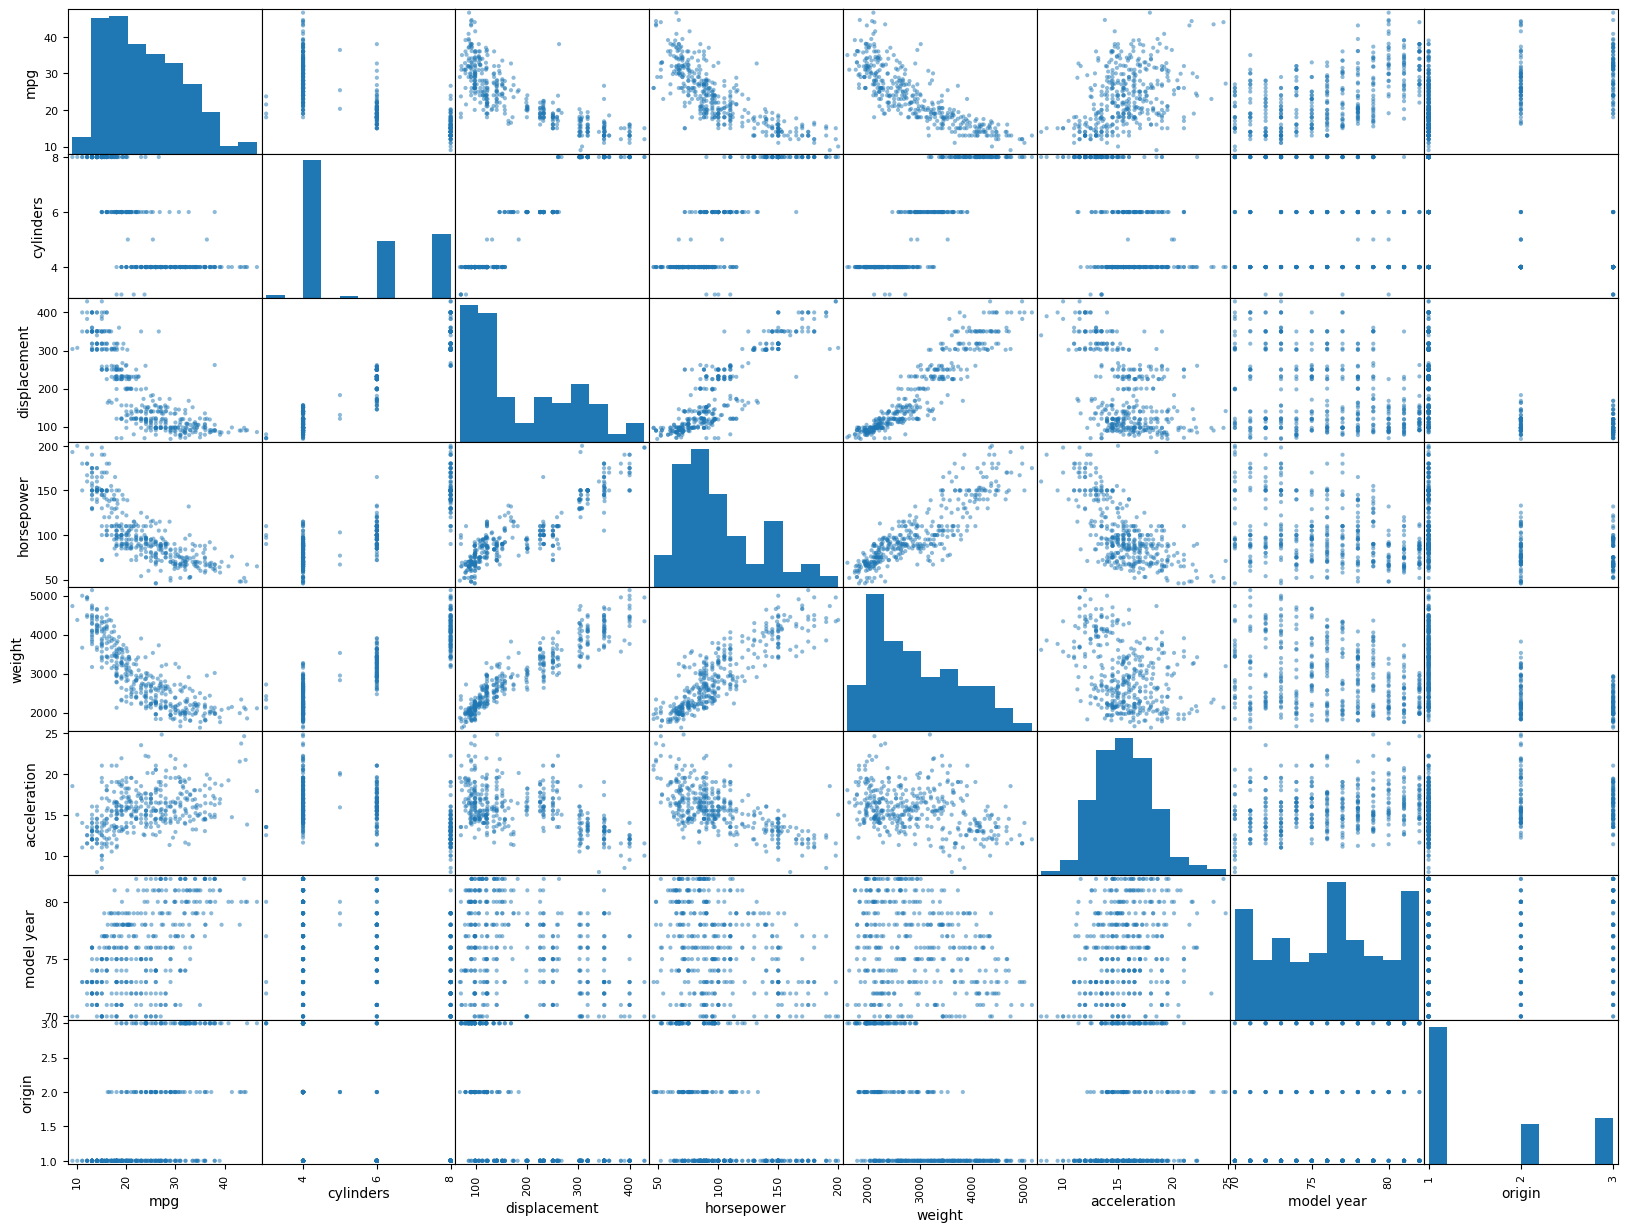

In [13]:
import matplotlib.pyplot as plt
pd.plotting.scatter_matrix(df,figsize=(20,15))
plt.show()

In [14]:
pd.crosstab(df['model year'],df['cylinders'],margins=True)

cylinders,3,4,5,6,8,All
model year,,,,,,
70,0,7,0,4,12,23
71,0,12,0,8,7,27
72,1,14,0,0,12,27
73,1,11,0,8,17,37
74,0,15,0,6,5,26
75,0,12,0,12,6,30
76,0,15,0,10,9,34
77,1,14,0,5,8,28
78,0,17,1,12,6,36


## Parallel Coordinates

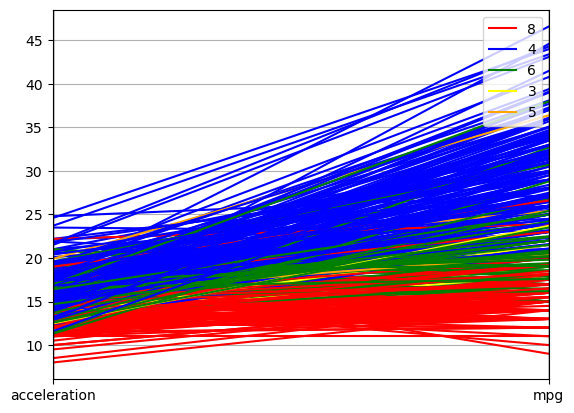

In [15]:
pd.plotting.parallel_coordinates(df,class_column='cylinders',cols=['acceleration','mpg'],color=['red','blue','green','yellow','orange'])
plt.show()

In [16]:
df.replace('chevrolet chevelle malibu','Car')

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,Car
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino
...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86,2790,15.6,82,1,ford mustang gl
394,44.0,4,97.0,52,2130,24.6,82,2,vw pickup
395,32.0,4,135.0,84,2295,11.6,82,1,dodge rampage
396,28.0,4,120.0,79,2625,18.6,82,1,ford ranger


# 147

In [17]:
df = pd.read_csv('supermarket_sales.csv')
df

,Unnamed: 0,invoice id,branch,city,customer type,gender,product line,unit price,quantity,tax 5%,total,date,time,payment,cogs,gross margin percentage,gross income,rating,day_of_week
0,0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,05-01-2019,13:08,Ewallet,522.83,4.761905,26.1415,9.1,Saturday
1,1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,08-03-2019,10:29,Cash,76.40,4.761905,3.8200,9.6,Friday
2,2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,03-03-2019,13:23,Credit card,324.31,4.761905,16.2155,7.4,Sunday
3,3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,27-01-2019,20:33,Ewallet,465.76,4.761905,23.2880,8.4,Sunday
4,4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,08-02-2019,10:37,Ewallet,604.17,4.761905,30.2085,5.3,Friday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,995,233-67-5758,C,Naypyitaw,Normal,Male,Health and beauty,40.35,1,2.0175,42.3675,29-01-2019,13:46,Ewallet,40.35,4.761905,2.0175,6.2,Tuesday
996,996,303-96-2227,B,Mandalay,Normal,Female,Home and lifestyle,97.38,10,48.6900,1022.4900,02-03-2019,17:16,Ewallet,973.80,4.761905,48.6900,4.4,Saturday
997,997,727-02-1313,A,Yangon,Member,Male,Food and beverages,31.84,1,1.5920,33.4320,09-02-2019,13:22,Cash,31.84,4.761905,1.5920,7.7,Saturday
998,998,347-56-2442,A,Yangon,Normal,Male,Home and lifestyle,65.82,1,3.2910,69.1110,22-02-2019,15:33,Cash,65.82,4.761905,3.2910,4.1,Friday


In [18]:
#1
df.head(8)

,Unnamed: 0,invoice id,branch,city,customer type,gender,product line,unit price,quantity,tax 5%,total,date,time,payment,cogs,gross margin percentage,gross income,rating,day_of_week
0,0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,05-01-2019,13:08,Ewallet,522.83,4.761905,26.1415,9.1,Saturday
1,1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,08-03-2019,10:29,Cash,76.40,4.761905,3.8200,9.6,Friday
2,2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,03-03-2019,13:23,Credit card,324.31,4.761905,16.2155,7.4,Sunday
3,3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,27-01-2019,20:33,Ewallet,465.76,4.761905,23.2880,8.4,Sunday
4,4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,08-02-2019,10:37,Ewallet,604.17,4.761905,30.2085,5.3,Friday
5,5,699-14-3026,C,Naypyitaw,Normal,Male,Electronic accessories,85.39,7,29.8865,627.6165,25-03-2019,18:30,Ewallet,597.73,4.761905,29.8865,4.1,Monday
6,6,355-53-5943,A,Yangon,Member,Female,Electronic accessories,68.84,6,20.6520,433.6920,25-02-2019,14:36,Ewallet,413.04,4.761905,20.6520,5.8,Monday
7,7,315-22-5665,C,Naypyitaw,Normal,Female,Home and lifestyle,73.56,10,36.7800,772.3800,24-02-2019,11:38,Ewallet,735.60,4.761905,36.7800,8.0,Sunday


In [19]:
df.fillna(df.mean(numeric_only=True),inplace = True)

In [20]:
#3
df['gender'].fillna(df['gender'].mode()[0],inplace=True)

C:\Users\LJENG\AppData\Local\Temp\ipykernel_7944\3166398562.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['gender'].fillna(df['gender'].mode()[0],inplace=True)


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unnamed: 0               1000 non-null   int64  
 1   invoice id               1000 non-null   object 
 2   branch                   1000 non-null   object 
 3   city                     1000 non-null   object 
 4   customer type            996 non-null    object 
 5   gender                   1000 non-null   object 
 6   product line             1000 non-null   object 
 7   unit price               1000 non-null   float64
 8   quantity                 1000 non-null   int64  
 9   tax 5%                   1000 non-null   float64
 10  total                    1000 non-null   float64
 11  date                     1000 non-null   object 
 12  time                     1000 non-null   object 
 13  payment                  1000 non-null   object 
 14  cogs                     

In [22]:
#3
df[(df['quantity']< 3) & ((df['rating']>8.5) | (df['total']>600))].shape[0]

45

In [23]:
#4
member_sum = df[(df['customer type']=='Member')]['total'].sum()
normal_sum = df[(df['customer type']=='Normal')]['total'].sum()
print(member_sum,normal_sum)

162991.8675 158480.511


In [24]:
df = pd.read_csv('ipl-matches.csv')
df

,ID,City,Date,Season,MatchNumber,Team1,Team2,Venue,TossWinner,TossDecision,SuperOver,WinningTeam,WonBy,Margin,method,Player_of_Match,Team1Players,Team2Players,Umpire1,Umpire2
0,1312200,Ahmedabad,2022-05-29,2022,Final,Rajasthan Royals,Gujarat Titans,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,bat,N,Gujarat Titans,Wickets,7.0,NaN,HH Pandya,"['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...","['WP Saha', 'Shubman Gill', 'MS Wade', 'HH Pan...",CB Gaffaney,Nitin Menon
1,1312199,Ahmedabad,2022-05-27,2022,Qualifier 2,Royal Challengers Bangalore,Rajasthan Royals,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,field,N,Rajasthan Royals,Wickets,7.0,NaN,JC Buttler,"['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ...","['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...",CB Gaffaney,Nitin Menon
2,1312198,Kolkata,2022-05-25,2022,Eliminator,Royal Challengers Bangalore,Lucknow Super Giants,"Eden Gardens, Kolkata",Lucknow Super Giants,field,N,Royal Challengers Bangalore,Runs,14.0,NaN,RM Patidar,"['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ...","['Q de Kock', 'KL Rahul', 'M Vohra', 'DJ Hooda...",J Madanagopal,MA Gough
3,1312197,Kolkata,2022-05-24,2022,Qualifier 1,Rajasthan Royals,Gujarat Titans,"Eden Gardens, Kolkata",Gujarat Titans,field,N,Gujarat Titans,Wickets,7.0,NaN,DA Miller,"['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...","['WP Saha', 'Shubman Gill', 'MS Wade', 'HH Pan...",BNJ Oxenford,VK Sharma
4,1304116,Mumbai,2022-05-22,2022,70,Sunrisers Hyderabad,Punjab Kings,"Wankhede Stadium, Mumbai",Sunrisers Hyderabad,bat,N,Punjab Kings,Wickets,5.0,NaN,Harpreet Brar,"['PK Garg', 'Abhishek Sharma', 'RA Tripathi', ...","['JM Bairstow', 'S Dhawan', 'M Shahrukh Khan',...",AK Chaudhary,NA Patwardhan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
945,335986,Kolkata,2008-04-20,2007/08,4,Kolkata Knight Riders,Deccan Chargers,Eden Gardens,Deccan Chargers,bat,N,Kolkata Knight Riders,Wickets,5.0,NaN,DJ Hussey,"['WP Saha', 'BB McCullum', 'RT Ponting', 'SC G...","['AC Gilchrist', 'Y Venugopal Rao', 'VVS Laxma...",BF Bowden,K Hariharan
946,335985,Mumbai,2008-04-20,2007/08,5,Mumbai Indians,Royal Challengers Bangalore,Wankhede Stadium,Mumbai Indians,bat,N,Royal Challengers Bangalore,Wickets,5.0,NaN,MV Boucher,"['L Ronchi', 'ST Jayasuriya', 'DJ Thornely', '...","['S Chanderpaul', 'R Dravid', 'LRPL Taylor', '...",SJ Davis,DJ Harper
947,335984,Delhi,2008-04-19,2007/08,3,Delhi Daredevils,Rajasthan Royals,Feroz Shah Kotla,Rajasthan Royals,bat,N,Delhi Daredevils,Wickets,9.0,NaN,MF Maharoof,"['G Gambhir', 'V Sehwag', 'S Dhawan', 'MK Tiwa...","['T Kohli', 'YK Pathan', 'SR Watson', 'M Kaif'...",Aleem Dar,GA Pratapkumar
948,335983,Chandigarh,2008-04-19,2007/08,2,Kings XI Punjab,Chennai Super Kings,"Punjab Cricket Association Stadium, Mohali",Chennai Super Kings,bat,N,Chennai Super Kings,Runs,33.0,NaN,MEK Hussey,"['K Goel', 'JR Hopes', 'KC Sangakkara', 'Yuvra...","['PA Patel', 'ML Hayden', 'MEK Hussey', 'MS Dh...",MR Benson,SL Shastri


In [25]:
 # 1.How many matches were won by Gujarat Titans in a Super Over ?
# df[(df['WinningTeam'] == 'Gujarat Titans') & (df['SuperOver'] == 'Y')]



# 2.How Many Matches won by Royal Challengers Bangalore Vs Kolkata Knight Riders.
# df[(df['WinningTeam'] == 'Royal Challengers Bangalore') & ((df['Team1']=='Kolkata Knight Riders') | (df['Team2']=='Kolkata Knight Riders')) ].shape[0]


# 3.How many Matches won by Toss Winner of the Match.
# df[df['TossWinner']==df["WinningTeam"]].shape[0]


# 4.In how many matches was the result decided by the D/L method and the match was won by wickets?
# df[(df['method']=='D/L') & (df['WonBy']=='Wickets')].shape[0]


# 5.In how many matches Toss won by Rajasthan Royals & Won the Match.
# df[(df['TossWinner']=='Rajasthan Royals') & (df['WinningTeam']== 'Rajasthan Royals')].shape[0] 


# 6.In how many matches V Kohli declared player of the match against Chennai Super Kings.
# df[(df['Player_of_Match']=='V Kohli') & ((df['Team1']=='Chennai Super Kings') | (df['Team2']=='Chennai Super Kings'))].shape[0] 



# 7.Which Team is the Toss Winner of the Final match Played in Dubai?
# df[(df['MatchNumber']=='Final') & (df['City']=='Dubai')]['TossWinner']

# 8.List out the Finals played by Kolkata Knight Riders in which Toss Won by Kolkata Knight Riders in the Finals and choose to 
# field.






In [26]:
 df[(df['method']=='D/L') & (df['WonBy']=='Wickets')].shape[0]

8

In [27]:
df.corr(numeric_only=True)

,ID,Margin
ID,1.00000,-0.02394
Margin,-0.02394,1.00000


In [28]:
df.sort_index(axis=1)

,City,Date,ID,Margin,MatchNumber,Player_of_Match,Season,SuperOver,Team1,Team1Players,Team2,Team2Players,TossDecision,TossWinner,Umpire1,Umpire2,Venue,WinningTeam,WonBy,method
0,Ahmedabad,2022-05-29,1312200,7.0,Final,HH Pandya,2022,N,Rajasthan Royals,"['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...",Gujarat Titans,"['WP Saha', 'Shubman Gill', 'MS Wade', 'HH Pan...",bat,Rajasthan Royals,CB Gaffaney,Nitin Menon,"Narendra Modi Stadium, Ahmedabad",Gujarat Titans,Wickets,NaN
1,Ahmedabad,2022-05-27,1312199,7.0,Qualifier 2,JC Buttler,2022,N,Royal Challengers Bangalore,"['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ...",Rajasthan Royals,"['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...",field,Rajasthan Royals,CB Gaffaney,Nitin Menon,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,Wickets,NaN
2,Kolkata,2022-05-25,1312198,14.0,Eliminator,RM Patidar,2022,N,Royal Challengers Bangalore,"['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ...",Lucknow Super Giants,"['Q de Kock', 'KL Rahul', 'M Vohra', 'DJ Hooda...",field,Lucknow Super Giants,J Madanagopal,MA Gough,"Eden Gardens, Kolkata",Royal Challengers Bangalore,Runs,NaN
3,Kolkata,2022-05-24,1312197,7.0,Qualifier 1,DA Miller,2022,N,Rajasthan Royals,"['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...",Gujarat Titans,"['WP Saha', 'Shubman Gill', 'MS Wade', 'HH Pan...",field,Gujarat Titans,BNJ Oxenford,VK Sharma,"Eden Gardens, Kolkata",Gujarat Titans,Wickets,NaN
4,Mumbai,2022-05-22,1304116,5.0,70,Harpreet Brar,2022,N,Sunrisers Hyderabad,"['PK Garg', 'Abhishek Sharma', 'RA Tripathi', ...",Punjab Kings,"['JM Bairstow', 'S Dhawan', 'M Shahrukh Khan',...",bat,Sunrisers Hyderabad,AK Chaudhary,NA Patwardhan,"Wankhede Stadium, Mumbai",Punjab Kings,Wickets,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
945,Kolkata,2008-04-20,335986,5.0,4,DJ Hussey,2007/08,N,Kolkata Knight Riders,"['WP Saha', 'BB McCullum', 'RT Ponting', 'SC G...",Deccan Chargers,"['AC Gilchrist', 'Y Venugopal Rao', 'VVS Laxma...",bat,Deccan Chargers,BF Bowden,K Hariharan,Eden Gardens,Kolkata Knight Riders,Wickets,NaN
946,Mumbai,2008-04-20,335985,5.0,5,MV Boucher,2007/08,N,Mumbai Indians,"['L Ronchi', 'ST Jayasuriya', 'DJ Thornely', '...",Royal Challengers Bangalore,"['S Chanderpaul', 'R Dravid', 'LRPL Taylor', '...",bat,Mumbai Indians,SJ Davis,DJ Harper,Wankhede Stadium,Royal Challengers Bangalore,Wickets,NaN
947,Delhi,2008-04-19,335984,9.0,3,MF Maharoof,2007/08,N,Delhi Daredevils,"['G Gambhir', 'V Sehwag', 'S Dhawan', 'MK Tiwa...",Rajasthan Royals,"['T Kohli', 'YK Pathan', 'SR Watson', 'M Kaif'...",bat,Rajasthan Royals,Aleem Dar,GA Pratapkumar,Feroz Shah Kotla,Delhi Daredevils,Wickets,NaN
948,Chandigarh,2008-04-19,335983,33.0,2,MEK Hussey,2007/08,N,Kings XI Punjab,"['K Goel', 'JR Hopes', 'KC Sangakkara', 'Yuvra...",Chennai Super Kings,"['PA Patel', 'ML Hayden', 'MEK Hussey', 'MS Dh...",bat,Chennai Super Kings,MR Benson,SL Shastri,"Punjab Cricket Association Stadium, Mohali",Chennai Super Kings,Runs,NaN


In [29]:
df = pd.DataFrame({
    'A':[1,6,7,3,4,9],
    'B':[6,6,8,4,6,7],
    'C':[2,2,5,5,6,4],
    'D':[8,9,4,8,8,8],
}
)
df

,A,B,C,D
0,1,6,2,8
1,6,6,2,9
2,7,8,5,4
3,3,4,5,8
4,4,6,6,8
5,9,7,4,8


In [30]:
df.sort_values(by=['D','C'])

,A,B,C,D
2,7,8,5,4
0,1,6,2,8
5,9,7,4,8
3,3,4,5,8
4,4,6,6,8
1,6,6,2,9


## APPLY CONACT MERGE GROUP BY

In [31]:
df = pd.DataFrame({
    'Name':['A','B','C','D'],
    'Marks':[65,32,89,75],
    'Percent':[60,30,85,70]
})
df

,Name,Marks,Percent
0,A,65,60
1,B,32,30
2,C,89,85
3,D,75,70


In [32]:
df['New']=0
df

,Name,Marks,Percent,New
0,A,65,60,0
1,B,32,30,0
2,C,89,85,0
3,D,75,70,0


In [33]:
df.set_index('Name',inplace=True)

In [34]:
df

,Marks,Percent,New
Name,,,
A,65,60,0
B,32,30,0
C,89,85,0
D,75,70,0


In [35]:
print(df.apply(sum,axis=0))
print(df.apply(sum,axis=1))

Marks      261
Percent    245
New          0
dtype: int64
Name
A    125
B     62
C    174
D    145
dtype: int64


In [36]:
df.apply(lambda x:x+2)

,Marks,Percent,New
Name,,,
A,67,62,2
B,34,32,2
C,91,87,2
D,77,72,2


In [37]:
df['Marks'].apply(lambda x:x+4)

Name
A    69
B    36
C    93
D    79
Name: Marks, dtype: int64

In [38]:
df

,Marks,Percent,New
Name,,,
A,65,60,0
B,32,30,0
C,89,85,0
D,75,70,0


In [39]:
df['Extra_Marks']=df['Marks'].apply(lambda x:x+4 if x>35 else x)

In [40]:
df

,Marks,Percent,New,Extra_Marks
Name,,,,
A,65,60,0,69
B,32,30,0,32
C,89,85,0,93
D,75,70,0,79


In [50]:
def grade(row):
    if row['Marks']>85:
        return 'A'
    elif row['Marks']>70:
        return 'B'
    elif row['Marks']>50:
        return 'C'
    else:
        return 'F'

In [51]:
df['grade'] =  df.apply(grade,axis=1)
df

,Marks,Percent,New,Extra_Marks,grade
Name,,,,,
A,65,60,0,69,C
B,32,30,0,32,F
C,89,85,0,93,A
D,75,70,0,79,B


In [45]:
def fun(val,x):
    return val*x
df.apply(fun,args=(2,))

,Marks,Percent,New,Extra_Marks
Name,,,,
A,130,120,0,138
B,64,60,0,64
C,178,170,0,186
D,150,140,0,158


## CONCATE

In [54]:
df1 = pd.DataFrame({
    'name':['A','B','C','D'],
    'value':[1,2,3,4]
})
df2 = pd.DataFrame({
    'name':['P','Q','R'],
    'value':[5,6,7]
})
print(df1)
print(df2)

  name  value
0    A      1
1    B      2
2    C      3
3    D      4
  name  value
0    P      5
1    Q      6
2    R      7


In [55]:
pd.concat([df1,df2],axis=1)

,name,value,name,value
0,A,1,P,5.0
1,B,2,Q,6.0
2,C,3,R,7.0
3,D,4,NaN,NaN


In [56]:
pd.concat([df1,df2],join='inner')

,name,value
0,A,1
1,B,2
2,C,3
3,D,4
0,P,5
1,Q,6
2,R,7


In [57]:
pd.concat([df1,df2],join='outer',ignore_index=True)

,name,value
0,A,1
1,B,2
2,C,3
3,D,4
4,P,5
5,Q,6
6,R,7
